In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
# selecione nodes.csv e edges.csv

In [3]:
nodes = pd.read_csv("../dados_de_extracao/nodes.csv")
edges = pd.read_csv("../dados_de_extracao/edges.csv")

G = nx.Graph()
G.add_nodes_from(nodes['id'])
for _, row in edges.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

print("N total:", G.number_of_nodes(), "L total:", G.number_of_edges())

# Maior componente conexo = rede baseline
components = list(nx.connected_components(G))
giant_nodes = max(components, key=len)
Gc = G.subgraph(giant_nodes).copy()

N = Gc.number_of_nodes()
L = Gc.number_of_edges()
print("Baseline -> N:", N, "L:", L, "densidade:", round(nx.density(Gc), 4))

N total: 3938 L total: 11410
Baseline -> N: 2987 L: 10432 densidade: 0.0023


In [4]:
import random

def calcular_metricas(g, n_amostras=500, seed_amostra=0):
    n = g.number_of_nodes()
    l = g.number_of_edges()
    graus = dict(g.degree())
    grau_medio = sum(graus.values()) / n
    densidade = nx.density(g)
    cc_medio = nx.average_clustering(g)
    cc_global = nx.transitivity(g)
    n_componentes = nx.number_connected_components(g)

    maior_comp = max(nx.connected_components(g), key=len)
    g_maior = g.subgraph(maior_comp)

    # distância média e diâmetro aproximados por amostragem
    random.seed(seed_amostra)
    nos = list(g_maior.nodes())
    distancias = []
    for _ in range(n_amostras):
        u, v = random.sample(nos, 2)
        try:
            d = nx.shortest_path_length(g_maior, u, v)
            distancias.append(d)
        except nx.NetworkXNoPath:
            continue
    dist_media = np.mean(distancias)
    diametro_aprox = max(distancias)  # aproximação do diâmetro (limite inferior)

    return {
        "N": n, "L": l, "densidade": densidade,
        "grau_medio": grau_medio, "n_componentes": n_componentes,
        "dist_media": dist_media, "diametro_aprox": diametro_aprox,
        "cc_medio": cc_medio, "cc_global": cc_global
    }

metricas_baseline = calcular_metricas(Gc)
metricas_baseline

{'N': 2987,
 'L': 10432,
 'densidade': 0.0023392279695604373,
 'grau_medio': 6.984934717107466,
 'n_componentes': 1,
 'dist_media': np.float64(5.032),
 'diametro_aprox': 10,
 'cc_medio': 0.6955430799036625,
 'cc_global': 0.25686953602978196}

In [5]:
N = Gc.number_of_nodes()
L = Gc.number_of_edges()
k_medio = 2 * L / N  # grau médio alvo

n_replicas = 20
resultados = {"ER": [], "WS": [], "BA": []}

# --- Erdos-Renyi: mesmo N e mesmo L (via G(n,m)) ---
for i in range(n_replicas):
    g_er = nx.gnm_random_graph(N, L, seed=i)
    resultados["ER"].append(calcular_metricas(g_er))

# --- Watts-Strogatz: mesmo N, grau medio ~k_medio, p a testar ---
k_ws = int(round(k_medio))
if k_ws % 2 != 0:
    k_ws += 1  # WS exige k par
p_rewire = 0.1  # podem testar 0.01, 0.1, 0.5

for i in range(n_replicas):
    g_ws = nx.watts_strogatz_graph(N, k_ws, p_rewire, seed=i)
    resultados["WS"].append(calcular_metricas(g_ws))

# --- Barabasi-Albert: mesmo N, m ajustado para aproximar L ---
m_ba = max(1, round(k_medio / 2))

for i in range(n_replicas):
    g_ba = nx.barabasi_albert_graph(N, m_ba, seed=i)
    resultados["BA"].append(calcular_metricas(g_ba))

print("k_medio alvo:", k_medio, "| k_ws usado:", k_ws, "| m_ba usado:", m_ba)

k_medio alvo: 6.984934717107466 | k_ws usado: 8 | m_ba usado: 3


In [6]:
def agregar(lista_dicts):
    df = pd.DataFrame(lista_dicts)
    return df.mean(numeric_only=True), df.std(numeric_only=True)

linhas = []
linhas.append({"rede": "Baseline", **metricas_baseline})

for modelo in ["ER", "WS", "BA"]:
    media, desvio = agregar(resultados[modelo])
    linha = {"rede": modelo}
    for col in media.index:
        linha[col] = f"{media[col]:.3f} (±{desvio[col]:.3f})"
    linhas.append(linha)

tabela_comparativa = pd.DataFrame(linhas)
tabela_comparativa

,rede,N,L,densidade,grau_medio,n_componentes,dist_media,diametro_aprox,cc_medio,cc_global
0,Baseline,2987,10432,0.002339,6.984935,1,5.032,10,0.695543,0.25687
1,ER,2987.000 (±0.000),10432.000 (±0.000),0.002 (±0.000),6.985 (±0.000),3.400 (±1.569),4.223 (±0.483),6.150 (±0.366),0.002 (±0.000),0.002 (±0.000)
2,WS,2987.000 (±0.000),11948.000 (±0.000),0.003 (±0.000),8.000 (±0.000),1.000 (±0.000),5.976 (±0.087),8.650 (±0.489),0.473 (±0.005),0.462 (±0.005)
3,BA,2987.000 (±0.000),8952.000 (±0.000),0.002 (±0.000),5.994 (±0.000),1.000 (±0.000),3.855 (±0.051),5.650 (±0.489),0.014 (±0.002),0.007 (±0.000)


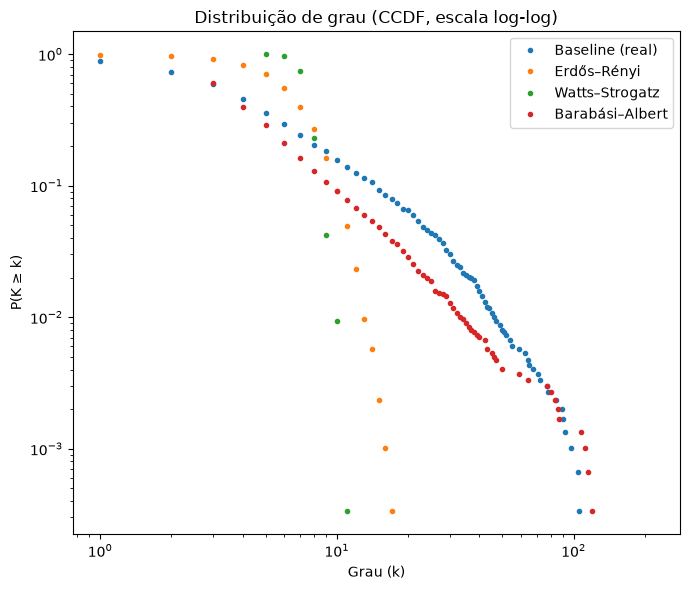

In [7]:
def graus_lista(g):
    return [d for _, d in g.degree()]

graus_baseline = graus_lista(Gc)
graus_er = graus_lista(nx.gnm_random_graph(N, L, seed=0))
graus_ws = graus_lista(nx.watts_strogatz_graph(N, k_ws, p_rewire, seed=0))
graus_ba = graus_lista(nx.barabasi_albert_graph(N, m_ba, seed=0))

def plot_ccdf(graus, label, ax):
    valores, contagens = np.unique(graus, return_counts=True)
    ccdf = 1 - np.cumsum(contagens) / len(graus)
    ax.loglog(valores, ccdf, marker='o', linestyle='none', markersize=3, label=label)

fig, ax = plt.subplots(figsize=(7, 6))
plot_ccdf(graus_baseline, "Baseline (real)", ax)
plot_ccdf(graus_er, "Erdős–Rényi", ax)
plot_ccdf(graus_ws, "Watts–Strogatz", ax)
plot_ccdf(graus_ba, "Barabási–Albert", ax)

ax.set_xlabel("Grau (k)")
ax.set_ylabel("P(K ≥ k)")
ax.set_title("Distribuição de grau (CCDF, escala log-log)")
ax.legend()
plt.tight_layout()
plt.show()

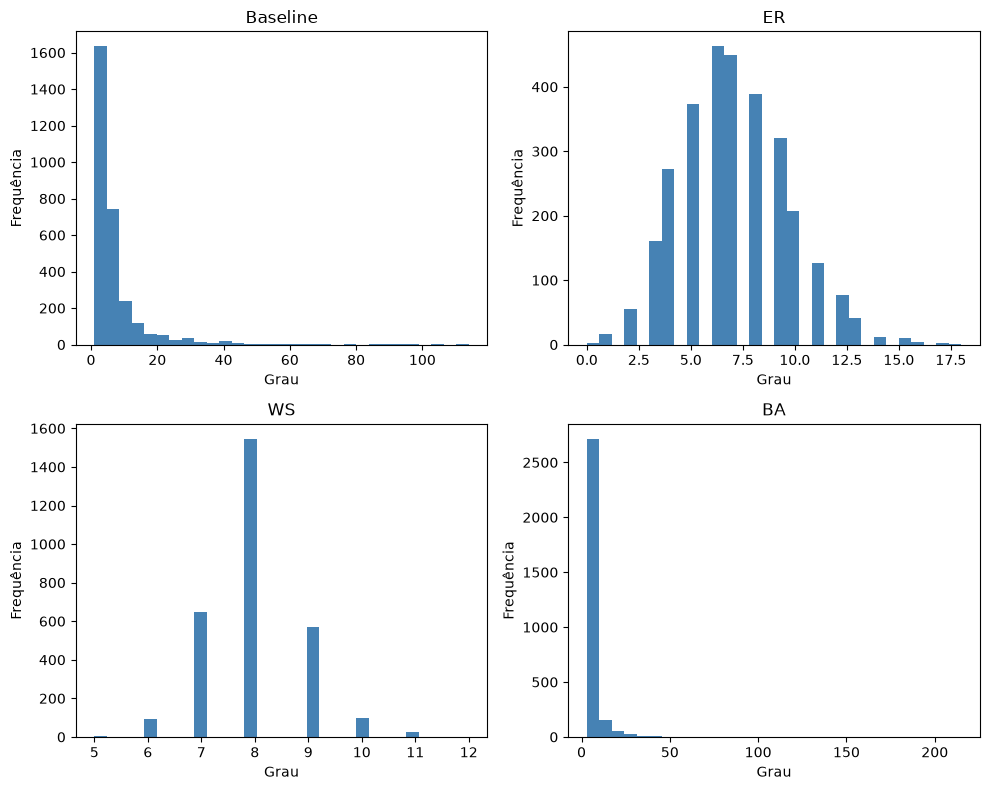

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
dados = [(graus_baseline, "Baseline"), (graus_er, "ER"), (graus_ws, "WS"), (graus_ba, "BA")]

for ax, (graus, nome) in zip(axs.flat, dados):
    ax.hist(graus, bins=30, color="steelblue")
    ax.set_title(nome)
    ax.set_xlabel("Grau")
    ax.set_ylabel("Frequência")

plt.tight_layout()
plt.show()

In [9]:
# Variação do parâmetro p no Watts-Strogatz
resultados_ws_p = {}
for p in [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]:
    lista = [calcular_metricas(nx.watts_strogatz_graph(N, k_ws, p, seed=i)) for i in range(10)]
    df = pd.DataFrame(lista)
    resultados_ws_p[p] = df.mean(numeric_only=True)

pd.DataFrame(resultados_ws_p).T[["dist_media","diametro_aprox" if "diametro_aprox" in df.columns else "diametro","cc_medio","cc_global"]]

,dist_media,diametro_aprox,cc_medio,cc_global
0.01,14.3796,26.7,0.623878,0.622257
0.05,7.3034,11.1,0.551456,0.544643
0.10,5.9464,8.7,0.470652,0.459980
0.30,4.6314,6.1,0.223850,0.211867
0.50,4.2764,6.0,0.082927,0.077075
1.00,4.1144,5.4,0.002433,0.002461


In [10]:
# Variação do parâmetro m no Barabasi-Albert
resultados_ba_m = {}
for m in [1, 2, 3, 4, 5, 6]:
    lista = [calcular_metricas(nx.barabasi_albert_graph(N, m, seed=i)) for i in range(10)]
    df = pd.DataFrame(lista)
    resultados_ba_m[m] = df.mean(numeric_only=True)

pd.DataFrame(resultados_ba_m).T[["L","grau_medio","dist_media","cc_medio","cc_global"]]

,L,grau_medio,dist_media,cc_medio,cc_global
1,2986.0,1.999330,7.7644,0.000000,0.000000
2,5970.0,3.997322,4.5342,0.011405,0.004138
3,8952.0,5.993974,3.8496,0.013960,0.007513
4,11932.0,7.989287,3.5176,0.015752,0.010397
5,14910.0,9.983261,3.3028,0.018052,0.013145
6,17886.0,11.975896,3.1426,0.019917,0.015541


In [11]:
# Modelo de Holme-Kim (powerlaw_cluster_graph)
# m = arestas por novo nó (como no BA); p = probabilidade de fechar triângulo

resultados_hk_p = {}
for p in [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]:
    lista = [calcular_metricas(nx.powerlaw_cluster_graph(N, m=3, p=p, seed=i)) for i in range(10)]
    df = pd.DataFrame(lista)
    resultados_hk_p[p] = df.mean(numeric_only=True)

tabela_hk = pd.DataFrame(resultados_hk_p).T
tabela_hk[["L","grau_medio","dist_media","diametro" if "diametro" in tabela_hk.columns else "diametro_aprox","cc_medio","cc_global"]]

,L,grau_medio,dist_media,diametro_aprox,cc_medio,cc_global
0.0,8952.0,5.993974,3.8296,5.7,0.014563,0.007443
0.1,8950.9,5.993237,3.8432,5.7,0.064688,0.019411
0.3,8948.7,5.991764,3.8628,5.9,0.169653,0.041181
0.5,8948.9,5.991898,3.8840,5.9,0.276681,0.059277
0.7,8948.8,5.991831,3.9526,6.2,0.393502,0.077286
0.9,8951.3,5.993505,4.1746,6.7,0.519668,0.098380


In [12]:
resultados_hk_grid = {}
for m in [3, 4, 5]:
    for p in [0.3, 0.5, 0.7, 0.9]:
        lista = [calcular_metricas(nx.powerlaw_cluster_graph(N, m=m, p=p, seed=i)) for i in range(10)]
        df = pd.DataFrame(lista)
        resultados_hk_grid[(m,p)] = df.mean(numeric_only=True)

pd.DataFrame(resultados_hk_grid).T[["L","grau_medio","cc_medio","cc_global","dist_media"]]

L  grau_medio  cc_medio  cc_global  dist_media
3 0.3   8948.7    5.991764  0.169653   0.041181      3.8628
  0.5   8948.9    5.991898  0.276681   0.059277      3.8840
  0.7   8948.8    5.991831  0.393502   0.077286      3.9526
  0.9   8951.3    5.993505  0.519668   0.098380      4.1746
4 0.3  11925.0    7.984600  0.134064   0.039711      3.4904
  0.5  11925.2    7.984734  0.222407   0.057857      3.4966
  0.7  11926.4    7.985537  0.314516   0.077201      3.5750
  0.9  11928.5    7.986943  0.426127   0.099020      3.7196
5 0.3  14894.9    9.973150  0.121772   0.035015      3.1860
  0.5  14893.0    9.971878  0.192098   0.048582      3.1886
  0.7  14897.6    9.974958  0.261932   0.068286      3.2640
  0.9  14903.1    9.978641  0.354365   0.099228      3.4622

In [13]:
lista_p1 = [calcular_metricas(nx.powerlaw_cluster_graph(N, m=3, p=1.0, seed=i)) for i in range(10)]
df_p1 = pd.DataFrame(lista_p1)
df_p1.mean(numeric_only=True)

N                 2987.000000
L                 8951.600000
densidade            0.002007
grau_medio           5.993706
n_componentes        1.000000
dist_media           4.523600
diametro_aprox       8.300000
cc_medio             0.589770
cc_global            0.109042
dtype: float64

In [14]:
from networkx.generators.community import LFR_benchmark_graph

def tentar_lfr(n, tau1, tau2, mu, avg_deg, min_com, max_com, seed=0, max_tent=5):
    for tentativa in range(max_tent):
        try:
            g = LFR_benchmark_graph(
                n=n, tau1=tau1, tau2=tau2, mu=mu,
                average_degree=avg_deg,
                min_community=min_com, max_community=max_com,
                seed=seed + tentativa,
                max_iters=1000
            )
            return g
        except Exception as e:
            print(f"tentativa {tentativa} falhou: {e}")
    return None

g_lfr2 = tentar_lfr(
    n=N, tau1=2.5, tau2=1.2, mu=0.1,
    avg_deg=9, min_com=30, max_com=250,
    max_tent=8
)

if g_lfr2 is not None:
    g_lfr2_simples = nx.Graph(g_lfr2)
    g_lfr2_simples.remove_edges_from(nx.selfloop_edges(g_lfr2_simples))
    print(calcular_metricas(g_lfr2_simples))
else:
    print("Não convergiu — tentar outros parâmetros")

tentativa 0 falhou: Could not assign communities; try increasing min_community
tentativa 1 falhou: Could not assign communities; try increasing min_community
tentativa 2 falhou: Could not assign communities; try increasing min_community
{'N': 2987, 'L': 13691, 'densidade': 0.0030700124742381084, 'grau_medio': 9.167057248074991, 'n_componentes': 1, 'dist_media': np.float64(4.012), 'diametro_aprox': 6, 'cc_medio': 0.1958895092693889, 'cc_global': 0.08144300652443975}


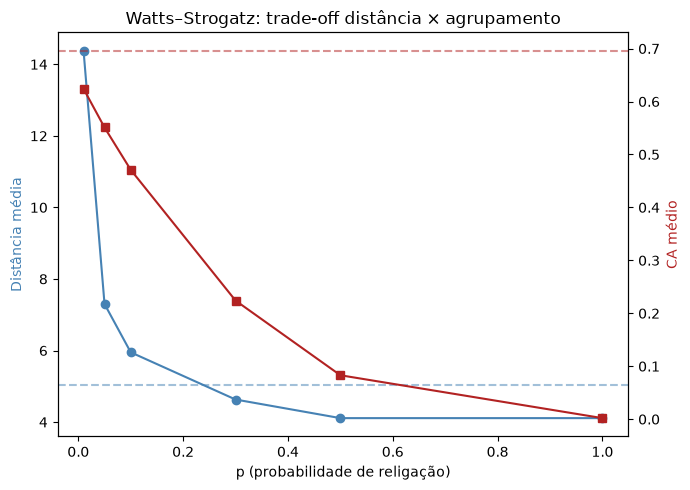

In [15]:
import matplotlib.pyplot as plt

ps = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0]
dist = [14.38, 7.30, 5.95, 4.63, 4.11, 4.11]  # usem os valores exatos que vocês têm
cc = [0.624, 0.551, 0.471, 0.224, 0.083, 0.002]

fig, ax1 = plt.subplots(figsize=(7,5))
ax1.plot(ps, dist, 'o-', color='steelblue', label='Distância média')
ax1.set_xlabel('p (probabilidade de religação)')
ax1.set_ylabel('Distância média', color='steelblue')
ax1.axhline(5.032, color='steelblue', linestyle='--', alpha=0.5)  # baseline

ax2 = ax1.twinx()
ax2.plot(ps, cc, 's-', color='firebrick', label='CA médio')
ax2.set_ylabel('CA médio', color='firebrick')
ax2.axhline(0.696, color='firebrick', linestyle='--', alpha=0.5)  # baseline

plt.title('Watts–Strogatz: trade-off distância × agrupamento')
plt.tight_layout()
plt.savefig('ws_tradeoff.png', dpi=150)
plt.show()

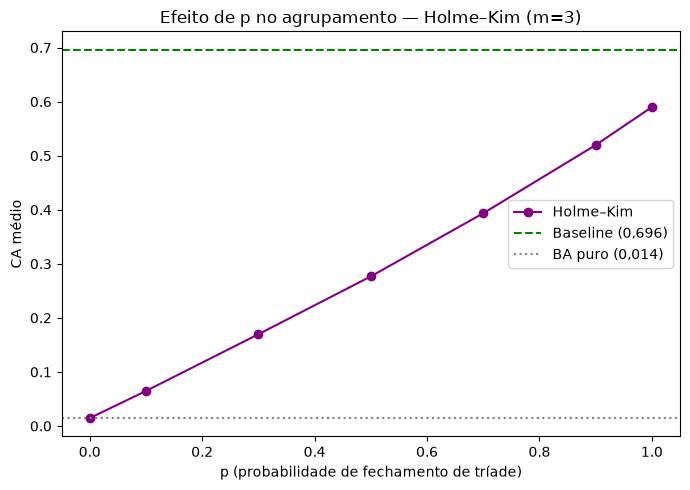

In [16]:
p_hk = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
cc_hk = [0.0146, 0.0647, 0.1697, 0.2767, 0.3935, 0.5197, 0.590]

plt.figure(figsize=(7,5))
plt.plot(p_hk, cc_hk, 'o-', color='purple', label='Holme–Kim')
plt.axhline(0.696, color='green', linestyle='--', label='Baseline (0,696)')
plt.axhline(0.014, color='gray', linestyle=':', label='BA puro (0,014)')
plt.xlabel('p (probabilidade de fechamento de tríade)')
plt.ylabel('CA médio')
plt.title('Efeito de p no agrupamento — Holme–Kim (m=3)')
plt.legend()
plt.tight_layout()
plt.savefig('hk_p_effect.png', dpi=150)
plt.show()